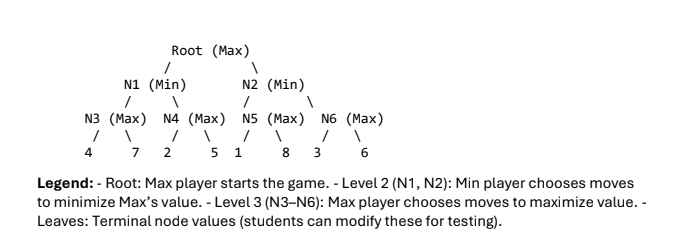

In [8]:
# Task 1: Minimax Algorithm Implementation
# 1. Implement the Minimax algorithm for the tree above.
# 2. Compute and print:
# o Minimax values for all nodes
# o Order in which nodes are visited
# 3. Add depth-limiting (depth = 2) and show updated Minimax values.
import math

class Node:
    def __init__(self, value=None, name=""):
        self.value = value
        self.name = name
        self.children = []
        self.minmax_value = None


def minimax(node, depth, maximizing_player, visit_order):
    if depth == 0 or not node.children:
        node.minmax_value = node.value
        visit_order.append(node.name)
        return node.value

    if maximizing_player:
        value = -math.inf
        for child in node.children:
            value = max(value, minimax(child, depth - 1, False, visit_order))
        node.minmax_value = value
        visit_order.append(node.name)
        return value
    else:
        value = math.inf
        for child in node.children:
            value = min(value, minimax(child, depth - 1, True, visit_order))
        node.minmax_value = value
        visit_order.append(node.name)
        return value


root = Node(name="Root")
n1   = Node(name="N1")
n2   = Node(name="N2")
root.children = [n1, n2]

n3 = Node(name="N3")
n4 = Node(name="N4")
n5 = Node(name="N5")
n6 = Node(name="N6")
n1.children = [n3, n4]
n2.children = [n5, n6]

l1 = Node(value=4, name="Leaf(4)")
l2 = Node(value=7, name="Leaf(7)")
l3 = Node(value=2, name="Leaf(2)")
l4 = Node(value=5, name="Leaf(5)")
l5 = Node(value=1, name="Leaf(1)")
l6 = Node(value=8, name="Leaf(8)")
l7 = Node(value=3, name="Leaf(3)")
l8 = Node(value=6, name="Leaf(6)")

n3.children = [l1, l2]
n4.children = [l3, l4]
n5.children = [l5, l6]
n6.children = [l7, l8]

visit_order = []
minimax(root, 3, True, visit_order)

print("Minimax Values:")
print(f"Root : {root.minmax_value}")
print(f"N1   : {n1.minmax_value}")
print(f"N2   : {n2.minmax_value}")
print(f"N3   : {n3.minmax_value}")
print(f"N4   : {n4.minmax_value}")
print(f"N5   : {n5.minmax_value}")
print(f"N6   : {n6.minmax_value}")

print("\nVisit Order:")
print( " -> ".join(visit_order))

for node in [root, n1, n2, n3, n4, n5, n6, l1, l2, l3, l4, l5, l6, l7, l8]:
    node.minmax_value = None

n3.value = 7
n4.value = 5
n5.value = 8
n6.value = 6

visit_order_dl = []
minimax(root, 2, True, visit_order_dl)

print("\nMinimax Values at depth = 2:")
print(f"Root: {root.minmax_value}")
print(f"N1: {n1.minmax_value}")
print(f"N2: {n2.minmax_value}")
print(f"N3: {n3.minmax_value}")
print(f"N4: {n4.minmax_value}")
print(f"N5: {n5.minmax_value}")
print(f"N6: {n6.minmax_value}")

print("\nVisit Order (depth = 2):")
print(" -> ".join(visit_order_dl))

Minimax Values:
Root : 6
N1   : 5
N2   : 6
N3   : 7
N4   : 5
N5   : 8
N6   : 6

Visit Order:
Leaf(4) -> Leaf(7) -> N3 -> Leaf(2) -> Leaf(5) -> N4 -> N1 -> Leaf(1) -> Leaf(8) -> N5 -> Leaf(3) -> Leaf(6) -> N6 -> N2 -> Root

Minimax Values at depth = 2:
Root: 6
N1: 5
N2: 6
N3: 7
N4: 5
N5: 8
N6: 6

Visit Order (depth = 2):
N3 -> N4 -> N1 -> N5 -> N6 -> N2 -> Root


In [9]:
# Task 2: Alpha-Beta Pruning
# 1. Implement Minimax with Alpha-Beta pruning on the same tree.
# 2. Track alpha and beta values.
# 3. Print:
# o Minimax values for all nodes
# o Nodes that are pruned
# 4. Compare the number of nodes visited with standard Minimax and explain why
# pruning reduces computationimport math

import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []
        self.minmax_value = None
        self.alpha = None
        self.beta = None

def alpha_beta_search(node, depth, alpha, beta, maximizing_player, pruned_nodes, computed_nodes):
    node.alpha = alpha
    node.beta = beta
    computed_nodes.append(node.value)

    if depth == 0 or not node.children:
        node.minmax_value = node.value
        return node.value

    if maximizing_player:
        value = -math.inf
        for i, child in enumerate(node.children):
            child_value = alpha_beta_search(child, depth - 1, alpha, beta, False, pruned_nodes, computed_nodes)
            value = max(value, child_value)
            alpha = max(alpha, value)
            if beta <= alpha:
                for remaining_child in node.children[i+1:]:
                    pruned_nodes.append(remaining_child.value)
                break
        node.minmax_value = value
        return value
    else:
        value = math.inf
        for i, child in enumerate(node.children):
            child_value = alpha_beta_search(child, depth - 1, alpha, beta, True, pruned_nodes, computed_nodes)
            value = min(value, child_value)
            beta = min(beta, value)
            if beta <= alpha:
                for remaining_child in node.children[i+1:]:
                    pruned_nodes.append(remaining_child.value)
                break
        node.minmax_value = value
        return value


root = Node('A')
n1   = Node('B')
n2   = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7  = Node(4)
n8  = Node(7)
n9  = Node(2)
n10 = Node(5)
n11 = Node(1)
n12 = Node(8)
n13 = Node(3)
n14 = Node(6)
n3.children = [n7,  n8]
n4.children = [n9,  n10]
n5.children = [n11, n12]
n6.children = [n13, n14]

pruned_nodes   = []
computed_nodes = []

alpha_beta_search(root, 3, -math.inf, math.inf, True, pruned_nodes, computed_nodes)

print("Minimax Values:")
print(f"A (Root): {root.minmax_value}")
print(f"B: {n1.minmax_value}")
print(f"C: {n2.minmax_value}")
print(f"D: {n3.minmax_value}")
print(f"E: {n4.minmax_value}")
print(f"F: {n5.minmax_value}")
print(f"G: {n6.minmax_value}")

print("\nAlpha-Beta Values:")
print(f"A: alpha={root.alpha}, beta={root.beta}")
print(f"B: alpha={n1.alpha},   beta={n1.beta}")
print(f"C: alpha={n2.alpha},   beta={n2.beta}")
print(f"D: alpha={n3.alpha},   beta={n3.beta}")
print(f"E: alpha={n4.alpha},   beta={n4.beta}")
print(f"F: alpha={n5.alpha},   beta={n5.beta}")
print(f"G: alpha={n6.alpha},   beta={n6.beta}")

print("\nNodes Visited :", computed_nodes)
print("Pruned Nodes  :", pruned_nodes if pruned_nodes else "None")

standard = 15
ab       = len(computed_nodes)
print(f"\nStandard Minimax nodes : {standard}")
print(f"Alpha-Beta nodes       : {ab}")
print(f"Nodes saved            : {standard - ab}")
print(f"Improvement            : {(1 - ab/standard)*100:.1f}% fewer nodes visited")

Minimax Values:
A (Root): 6
B: 5
C: 6
D: 7
E: 5
F: 8
G: 6

Alpha-Beta Values:
A: alpha=-inf, beta=inf
B: alpha=-inf,   beta=inf
C: alpha=5,   beta=inf
D: alpha=-inf,   beta=inf
E: alpha=-inf,   beta=7
F: alpha=5,   beta=inf
G: alpha=5,   beta=8

Nodes Visited : ['A', 'B', 'D', 4, 7, 'E', 2, 5, 'C', 'F', 1, 8, 'G', 3, 6]
Pruned Nodes  : None

Standard Minimax nodes : 15
Alpha-Beta nodes       : 15
Nodes saved            : 0
Improvement            : 0.0% fewer nodes visited


WHY PRUNING REDUCES COMPUTATION:
Alpha-beta pruning reduces computation by stopping evaluation of a branch as soon as it's clear that the current best option cannot be improved, just like you stop looking at other houses after finding your dream home at a great price.

In [13]:
# Task 3
# 1. Modify the tree by changing leaf values or adding an extra branch.
# 2. Run Minimax and Alpha-Beta again.
# 3. Print:
# o Updated Minimax values
# o Nodes pruned
# o Optimal path for Max from root to leaf
# 4. Comment on any changes in the root value or pruning behavior.
import math

class Node:
    def __init__(self, value=None):
        self.value = value
        self.children = []
        self.minmax_value = None
        self.alpha = None
        self.beta = None

def alpha_beta_search(node, depth, alpha, beta, maximizing_player, pruned_nodes, computed_nodes):
    node.alpha = alpha
    node.beta = beta
    computed_nodes.append(node.value)

    if depth == 0 or not node.children:
        node.minmax_value = node.value
        return node.value

    if maximizing_player:
        value = -math.inf
        for i, child in enumerate(node.children):
            child_value = alpha_beta_search(child, depth - 1, alpha, beta, False, pruned_nodes, computed_nodes)
            value = max(value, child_value)
            alpha = max(alpha, value)
            if beta <= alpha:
                for remaining_child in node.children[i+1:]:
                    pruned_nodes.append(remaining_child.value)
                break
        node.minmax_value = value
        return value
    else:
        value = math.inf
        for i, child in enumerate(node.children):
            child_value = alpha_beta_search(child, depth - 1, alpha, beta, True, pruned_nodes, computed_nodes)
            value = min(value, child_value)
            beta = min(beta, value)
            if beta <= alpha:
                for remaining_child in node.children[i+1:]:
                    pruned_nodes.append(remaining_child.value)
                break
        node.minmax_value = value
        return value

def find_optimal_path(node, maximizing=True):
    path = [node.value]
    if not node.children:
        return path
    if maximizing:
        best_child = max(node.children, key=lambda x: x.minmax_value)
    else:
        best_child = min(node.children, key=lambda x: x.minmax_value)
    path.extend(find_optimal_path(best_child, not maximizing))
    return path


root = Node('A')
n1   = Node('B')
n2   = Node('C')
root.children = [n1, n2]

n3 = Node('D')
n4 = Node('E')
n5 = Node('F')
n6 = Node('G')
n1.children = [n3, n4]
n2.children = [n5, n6]

n7  = Node(10)
n8  = Node(2)
n9  = Node(1)
n10 = Node(3)
n11 = Node(100)
n12 = Node(0)
n13 = Node(5)
n14 = Node(4)

n3.children = [n7,  n8]
n4.children = [n9,  n10]
n5.children = [n11, n12]
n6.children = [n13, n14]

n15 = Node('H')
n16 = Node(8)
n17 = Node(7)
n18 = Node(6)
n19 = Node(9)
n15.children = [n16, n17, n18, n19]
n2.children.append(n15)

pruned_nodes   = []
computed_nodes = []

alpha_beta_search(root, 3, -math.inf, math.inf, True, pruned_nodes, computed_nodes)

print("Minimax Values:")
print(f"A: {root.minmax_value}")
print(f"B: {n1.minmax_value}")
print(f"C: {n2.minmax_value}")
print(f"D: {n3.minmax_value}")
print(f"E: {n4.minmax_value}")
print(f"F: {n5.minmax_value}")
print(f"G: {n6.minmax_value}")
print(f"H: {n15.minmax_value}")

print("\nNodes Visited :", computed_nodes)
print("Pruned Nodes  :", pruned_nodes if pruned_nodes else "None")

print("\nOptimal Path:")
path = find_optimal_path(root, maximizing=True)
print(" -> ".join(str(n) for n in path))


Minimax Values:
A: 5
B: 3
C: 5
D: 10
E: 3
F: 100
G: 5
H: 8

Nodes Visited : ['A', 'B', 'D', 10, 2, 'E', 1, 3, 'C', 'F', 100, 0, 'G', 5, 4, 'H', 8]
Pruned Nodes  : [7, 6, 9]

Optimal Path:
A -> C -> G -> 5


In [48]:
# Task 4 Basic CSP Modelling
# Create a CSP model with three variables:
# • Variables: A, B, C
# • Domain: {0,1,2,3}
# Apply the following constraints:
# 1. A ≠ B
# 2. B ≠ C
# 3. A + B ≤ 4
# Requirements:
# • Define variables using model.new_int_var()
# • Add constraints using model.add()
# • Solve the model
# • Print the values of A, B, and C
from ortools.sat.python import cp_model

model = cp_model.CpModel()

A = model.new_int_var(0, 3, "A")
B = model.new_int_var(0, 3, "B")
C = model.new_int_var(0, 3, "C")

model.add(A != B)
model.add(B != C)
model.add(A + B <= 4)
solver = cp_model.CpSolver()
status = solver.solve(model)

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"A = {solver.value(A)}")
    print(f"B = {solver.value(B)}")
    print(f"C = {solver.value(C)}")
else:
    print("No solution found.")

A = 0
B = 1
C = 3


In [57]:
# Task 5 Print All Possible Solutions
# Modify the program from Task 1 to print all possible valid solutions.
# Hint:
# Use the solver parameter:
# solver.parameters.enumerate_all_solutions = True
# Also implement a solution callback class to print each solution.
# Output should show all valid assignments of A, B, and C.

from ortools.sat.python import cp_model

class VarArraySolutionPrinter(cp_model.CpSolverSolutionCallback):
    def __init__(self, variables: list[cp_model.IntVar]):
        cp_model.CpSolverSolutionCallback.__init__(self)
        self.__variables = variables
        self.__solution_count = 0

    def on_solution_callback(self) -> None:
        self.__solution_count += 1
        for v in self.__variables:
            print(f"{v}={self.value(v)}", end=" ")
        print()

    @property
    def solution_count(self) -> int:
        return self.__solution_count

model = cp_model.CpModel()
A = model.new_int_var(0, 3, "A")
B = model.new_int_var(0, 3, "B")
C = model.new_int_var(0, 3, "C")

model.add(A != B)
model.add(B != C)
model.add(A + B <= 4)
solver = cp_model.CpSolver()
solution_printer = VarArraySolutionPrinter([A, B, C])

solver.parameters.enumerate_all_solutions = True

In [56]:
# Task 6 Simple Optimization Problem
# Create a CSP model with:
# Variables: x, y, z
# Domain: 0–20
# Constraints:
# x + 2y + z ≤ 20
# 3x + y ≤ 18
# Objective Function:
# maximize 4x + 2y + z
# Requirements:
# • Define variables
# • Add constraints
# • Define the objective function
# • Solve the model
# • Print:
# o Optimal value
# o Values of x, y, and z
from ortools.sat.python import cp_model

model = cp_model.CpModel()

x = model.new_int_var(0, 20, "x")
y = model.new_int_var(0, 20, "y")
z = model.new_int_var(0, 20, "z")

model.add(x + 2*y + z <= 20)
model.add(3*x + y <= 18)

model.maximize(4*x + 2*y + z)

solver = cp_model.CpSolver()
status = solver.solve(model)

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    print(f"Optimal value = {solver.objective_value}")
    print(f"x = {solver.value(x)}")
    print(f"y = {solver.value(y)}")
    print(f"z = {solver.value(z)}")
else:
    print("No solution found.")

print(f"Status: {solver.status_name(status)}")

Optimal value = 38.0
x = 6
y = 0
z = 14
Status: OPTIMAL


In [52]:
# Task 7 N-Queens Variation
# Write a Python program using OR-Tools to solve the 4-Queens problem.
# Requirements:
# 1. No two queens share the same row
# 2. No two queens share the same diagonal
# 3. Print at least one valid solution
# Example output format:
# _ Q _ _
# _ _ _ Q
# Q _ _ _
# _ _ Q _
from ortools.sat.python import cp_model

model = cp_model.CpModel()

board_size = 4
queens = [model.new_int_var(0, board_size - 1, f"x_{i}") for i in range(board_size)]

model.add_all_different(queens)

model.add_all_different(queens[i] + i for i in range(board_size))
model.add_all_different(queens[i] - i for i in range(board_size))

solver = cp_model.CpSolver()
status = solver.solve(model)

if status == cp_model.OPTIMAL or status == cp_model.FEASIBLE:
    for i in range(board_size):
        for j in range(board_size):
            if solver.value(queens[j]) == i:
                print("Q", end=" ")
            else:
                print("_", end=" ")
        print()
else:
    print("No solution found.")

_ Q _ _ 
_ _ _ Q 
Q _ _ _ 
_ _ Q _ 
